In [1]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import process_probe as pp
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *
import optuna # Import Optuna

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  pyr  sst  vip  
0           0           0    1    0    0  
1           0           0    1    0    0  
2           0           0    1    0    0  
3           0           4    0    0    0  
4           0           0    0    0    0  


In [ ]:
# Session obj contains stimulus, channel, and unit information
output_dir  = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022'
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)

# hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
seqlength = 750
num_epochs = 15 # 
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
batch_size = 32

In [41]:
# Spikes obj contains Spike matrix
seqlength = 50
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
spikes_obj.truncate(seqlength)
# spikes_obj.convolve_with_gaussian() # skip convolution
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.truncate(seqlength) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

100%|██████████| 8/8 [03:24<00:00, 25.62s/it]


In [42]:
chani = 5 # deep layer
bandi = 0 # broadband

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

In [47]:
def objective(trial):
    """Optuna objective function to minimize validation loss."""

    # --- Suggest Hyperparameters ---
    embedding_dim = trial.suggest_categorical("embedding_dim", [32, 64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 1, 6)

    # Ensure num_heads is a divisor of embedding_dim
    possible_heads = [h for h in [1, 2, 4, 8, 16] if embedding_dim % h == 0]
    if not possible_heads: # Fallback if no divisors found (shouldn't happen with choices above)
         possible_heads = [1]
    num_heads = trial.suggest_categorical("num_heads", possible_heads)

    dropout = trial.suggest_float("dropout", 0.05, 0.5, step=0.05)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # --- Instantiate Model ---
    model = models.SpikingTransformer(
        input_size=input_size, # Use global num_neurons
        seqlength=seqlength,    # Use global seqlength
        embedding_dim=embedding_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    criterion = torch.nn.MSELoss()
    
    # --- Train and Evaluate ---
    processor = models.process_model(model, criterion, device)

    # Use val_dataloader as the 'test_dataloader' for evaluation within train
    # Train for a fixed number of epochs for hyperparameter comparison
    # You might need more epochs in final training
    num_optuna_epochs = 10 # Adjust as needed - balance speed and convergence

    transformer_train_loss, transformer_test_loss = processor.train(train_dataloader,
                                        test_dataloader , num_optuna_epochs, lr=lr, weight_decay=weight_decay)

    # --- Return the metric to minimize (e.g., final validation loss) ---
    final_val_loss = transformer_test_loss[-1]

    # --- Optional: Optuna Pruning (Stop unpromising trials early) ---
    trial.report(final_val_loss, step=num_optuna_epochs - 1)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return final_val_loss # Optuna minimizes this value

In [48]:
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)

study_name = "spiking-transformer-optimization-fixed-bs" # Updated name
storage_name = output_dir_models / f"{study_name}.db"

study = optuna.create_study(
    direction="minimize",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner()
)

print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=15)


[I 2025-05-06 13:31:34,736] A new study created in memory with name: no-name-678d5951-b2e5-4d59-b2a6-4246e9eb9412


Sampler is TPESampler


[I 2025-05-06 13:32:33,084] Trial 0 finished with value: 0.6990865046999096 and parameters: {'embedding_dim': 128, 'num_layers': 3, 'num_heads': 1, 'dropout': 0.5, 'lr': 5.246028048400779e-05, 'weight_decay': 2.647914407666069e-05}. Best is trial 0 with value: 0.6990865046999096.
[I 2025-05-06 13:33:44,059] Trial 1 finished with value: 0.5629737511672804 and parameters: {'embedding_dim': 64, 'num_layers': 4, 'num_heads': 1, 'dropout': 0.45, 'lr': 0.0024375277931110648, 'weight_decay': 0.005803179535672942}. Best is trial 1 with value: 0.5629737511672804.
[I 2025-05-06 13:35:50,924] Trial 2 finished with value: 0.6367258184251532 and parameters: {'embedding_dim': 32, 'num_layers': 5, 'num_heads': 4, 'dropout': 0.5, 'lr': 0.00012042339997547708, 'weight_decay': 0.00019466818654984637}. Best is trial 1 with value: 0.5629737511672804.
[I 2025-05-06 13:36:47,262] Trial 3 finished with value: 0.41399427087961044 and parameters: {'embedding_dim': 64, 'num_layers': 3, 'num_heads': 1, 'dropout'

In [49]:
# Print the best hyperparameters 
best_params   = study.best_params
best_accuracy = study.best_value
print("Best Hyperparameters: ", best_params)
print("Best Acc: ", best_accuracy)


Best Hyperparameters:  {'embedding_dim': 256, 'num_layers': 3, 'num_heads': 8, 'dropout': 0.35000000000000003, 'lr': 0.000719159294950142, 'weight_decay': 4.8638880846827035e-05}
Best Acc:  0.2866948621462932


In [50]:
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = 64, num_heads = 8, num_layers = 1,
                                                                   dropout=0.15), criterion, device)

transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer, lr = 0.007, weight_decay=6.5e-05)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.3113
transformer  test loss:  0.3162


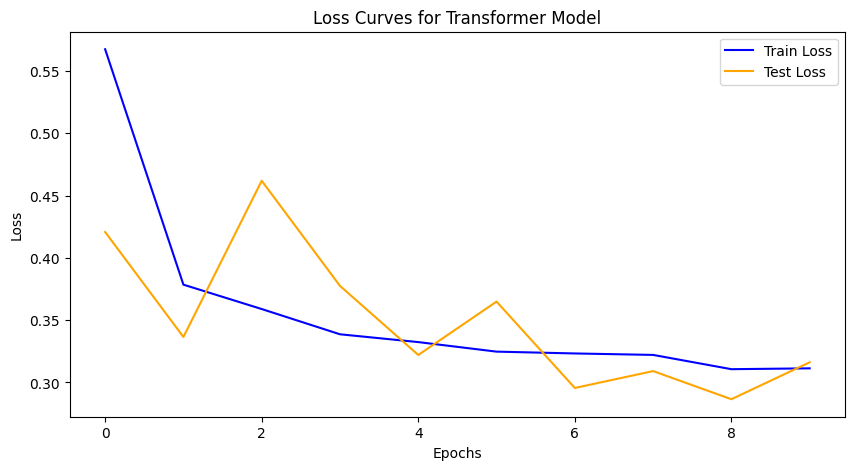

In [51]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(transformer_train_loss, label='Train Loss', color='blue')
ax.plot(transformer_test_loss, label='Test Loss', color='orange')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves for Transformer Model')
ax.legend()
plt.show()


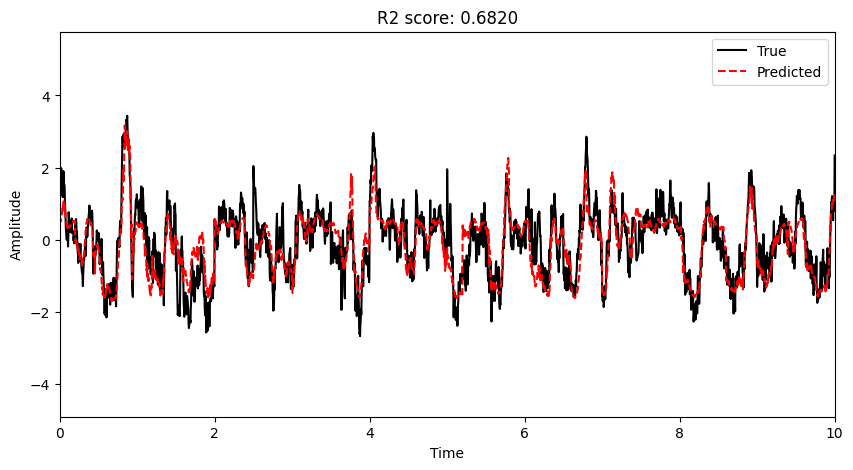

In [ ]:
test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
plt.show()



In [65]:
import importlib
import IntegratedGradient
importlib.reload(IntegratedGradient)
from IntegratedGradient import IntegratedGradient
import tqdm

attr_dur = 720
X_attr = torch.tensor(spikes_obj.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)

ig = IntegratedGradient(transformer_model.model.train().to(device), method='last time point', seqlength=seqlength) 
attrs = ig.run(X_attr, baselines = 0, n_steps = 50)

100%|██████████| 3600/3600 [42:52<00:00,  1.40it/s]  


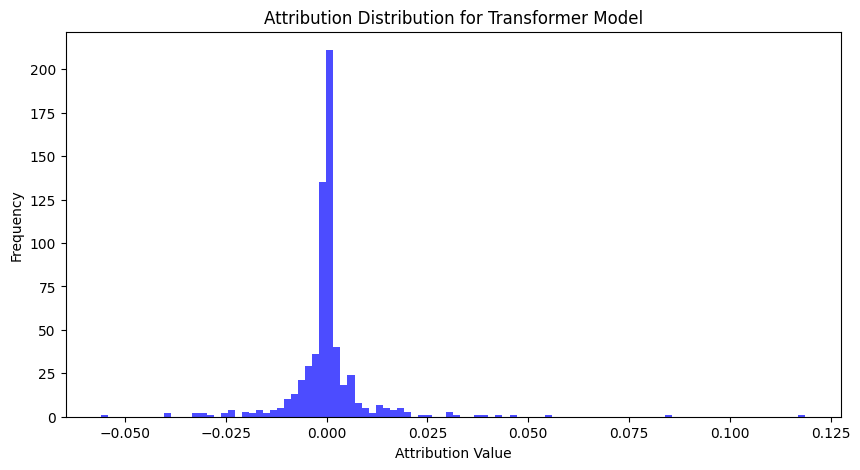

In [89]:
mean_attr_transformer = np.mean(attrs.cpu().numpy(), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(mean_attr_transformer, bins=100, color='blue', alpha=0.7)
ax.set_xlabel('Attribution Value')
ax.set_ylabel('Frequency')
ax.set_title('Attribution Distribution for Transformer Model')
plt.show()


In [88]:
gru_model = models.process_model(models.GRUnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
gru_train_loss, gru_test_loss = gru_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'GRU  train loss: {gru_train_loss[-1]:.4f}')
print(f'GRU  test loss: {gru_test_loss[-1]:.4f}')

GRU  train loss: 0.2942
GRU  test loss: 0.3153


In [90]:
ig2 = IntegratedGradient(gru_model.model.train().to(device), method='last time point', seqlength=seqlength) 
attrs2 = ig2.run(X_attr, baselines = 0, n_steps = 50)

100%|██████████| 3600/3600 [09:03<00:00,  6.62it/s]


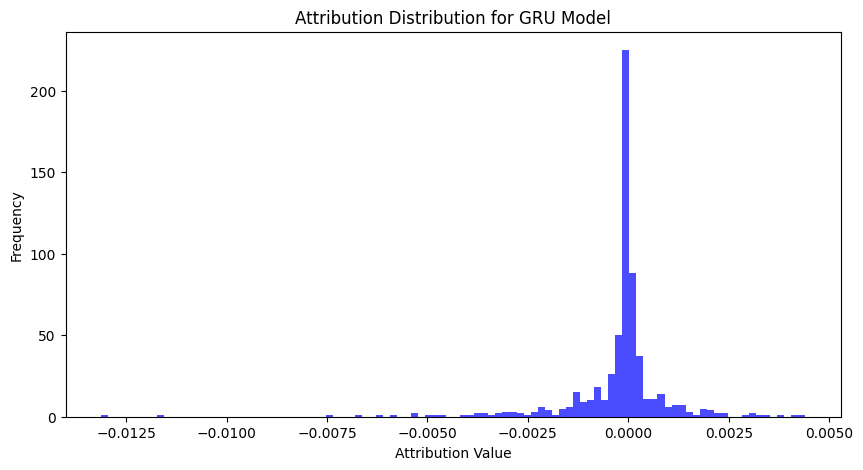

In [91]:
mean_attr_gru = np.mean(attrs2.cpu().numpy(), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(mean_attr_gru, bins=100, color='blue', alpha=0.7)
ax.set_xlabel('Attribution Value')
ax.set_ylabel('Frequency')
ax.set_title('Attribution Distribution for GRU Model')
plt.show()

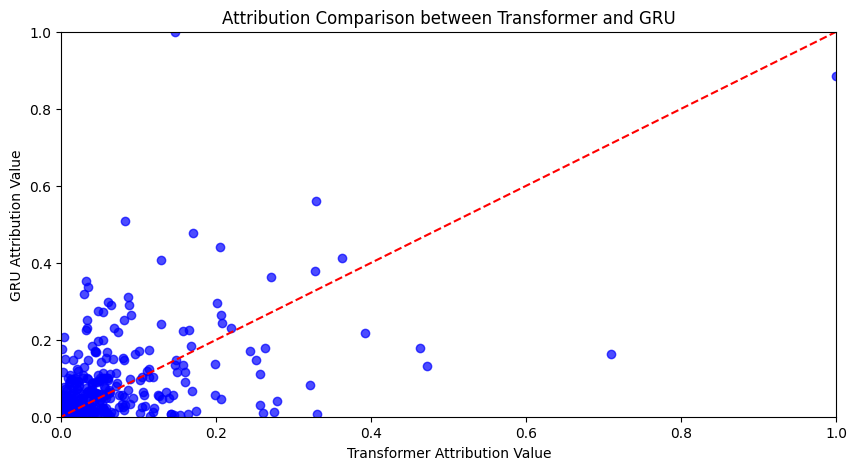

In [105]:
# import minmax scaler
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
scaled_mean_attr_transformer = scaler.fit_transform(mean_attr_transformer.reshape(-1, 1))

fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(scaler.fit_transform(np.abs(mean_attr_transformer).reshape(-1, 1)),
           scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), color='blue', alpha=0.7)
ax.set_xlabel('Transformer Attribution Value')
ax.set_ylabel('GRU Attribution Value')
ax.set_title('Attribution Comparison between Transformer and GRU')
ax.plot([-1, 1], [-1, 1], 'r--') # Diagonal line for reference
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

In [ ]:
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.2767
LSTM  test loss: 0.3002


In [98]:
ig3 = IntegratedGradient(lstm_model.model.train().to(device), method='last time point', seqlength=seqlength)
attrs3 = ig3.run(X_attr, baselines = 0, n_steps = 50)
mean_attr_lstm = np.mean(attrs3.cpu().numpy(), axis=0)

100%|██████████| 3600/3600 [09:26<00:00,  6.36it/s]


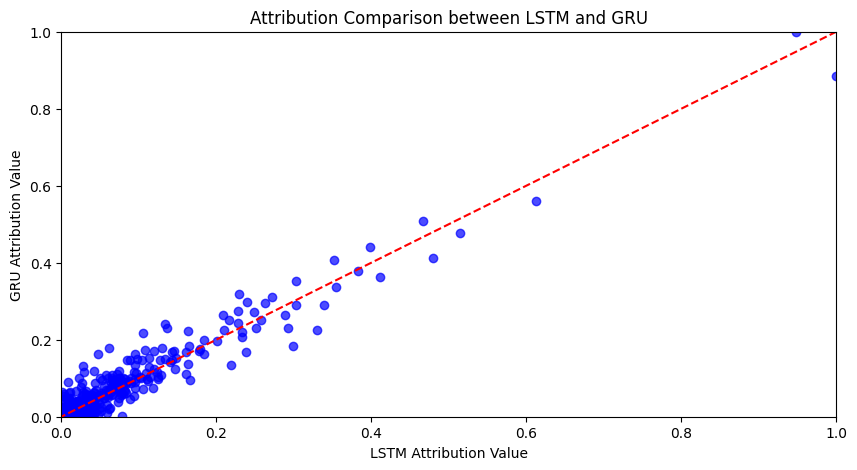

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(scaler.fit_transform(np.abs(mean_attr_lstm).reshape(-1, 1)),
           scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), color='blue', alpha=0.7)
ax.set_xlabel('LSTM Attribution Value')
ax.set_ylabel('GRU Attribution Value')
ax.set_title('Attribution Comparison between LSTM and GRU')
ax.plot([-1, 1], [-1, 1], 'r--') # Diagonal line for reference
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()